# Ülke Verileri Üzerinde Kümeleme Analizi (Gözetimsiz Öğrenme Ödevi)

Bu çalışma, derste `29-country_data.csv` veri seti üzerinde başladığımız K-Means ve PCA çalışmasının kapsamlı bir ödev incelemesidir.

### Ödevin Kapsamı ve İncelediğimiz Sorular:
1. **PCA Etkisi**: Veriyi 9 değişkenli ham ölçeklenmiş haliyle mi kümelemek daha mantıklı, yoksa PCA ile 3 boyuta indirgeyip kümelemek mi?
2. **Farklı Kümeleme Algoritmaları**: K-Means dışında Hiyerarşik Kümeleme (Agglomerative), Gaussian Mixture Models (GMM), DBSCAN ve HDBSCAN modellerinin denenmesi.
3. **Küme Sayısı ve Yapısı**: Sabit küme sayısı ($k=3$) isteyen algoritmalar ile kendi küme sayısını bulan yoğunluk tabanlı (DBSCAN/HDBSCAN) algoritmaların karşılaştırılması.
4. **Dünya Haritası ve Konjonktür İncelemesi**: Elde edilen sınıfları Plotly dünya haritasında gösterip Türkiye, Doğu Avrupa, Afrika ve Amerika ülkelerinin durumunu değerlendirmek.


## 1. Gerekli Kütüphanelerin Yüklenmesi

Analizde kullanacağımız temel veri bilimi, makine öğrenmesi ve görselleştirme kütüphanelerini içe aktarıyoruz.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, HDBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

# Grafiklerin genel stil ayarları
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("Kütüphaneler hazır.")


Kütüphaneler hazır.


## 2. Veri Yükleme ve Keşifsel Analiz (EDA)

Verimiz 167 ülkeye ait 9 sosyo-ekonomik ve sağlık göstergesini içermektedir (`child_mort`, `exports`, `health`, `imports`, `income`, `inflation`, `life_expec`, `total_fer`, `gdpp`).


In [2]:
# Veri setini okuyalım
df = pd.read_csv("29-country_data.csv")

print(f"Toplam Ülke Sayısı: {df.shape[0]}, Değişken Sayısı: {df.shape[1]}")
df.head()


Toplam Ülke Sayısı: 167, Değişken Sayısı: 10


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
# Eksik değer ve veri tipi kontrolü
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


## 3. Veri Ön İşleme (MinMax Scaling) ve PCA Dönüşümü

Mesafe tabanlı kümeleme algoritmalarında (Öklid mesafesi vb.) değişkenlerin farklı ölçeklerde olması (örneğin kişi başı gelir 40.000 iken doğurganlık oranının 2 olması) sonuçları saptırır. Bu yüzden tüm sayısal sütunları `MinMaxScaler` ile 0-1 aralığına getiriyoruz.

Ardından 9 değişkenli verimizin varyansını koruyarak 3 boyuta indirgemek için `PCA` uyguluyoruz.


In [4]:
# Sayısal sütunları seçip 0-1 arasına ölçeklendiriyoruz
feature_cols = df.drop(columns=['country']).columns
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[feature_cols])
scaled_df = pd.DataFrame(scaled_data, columns=feature_cols)

# PCA ile 3 temel bileşen oluşturuyoruz
pca = PCA(n_components=3, random_state=42)
pca_data = pca.fit_transform(scaled_df)
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2', 'PC3'])

# Varyans oranlarını inceleyelim
var_ratios = pca.explained_variance_ratio_
print(f"PC1: %{var_ratios[0]*100:.1f}, PC2: %{var_ratios[1]*100:.1f}, PC3: %{var_ratios[2]*100:.1f}")
print(f"3 Bileşenin Toplam Açıklağı Varyans: %{sum(var_ratios)*100:.1f}")


PC1: %55.0, PC2: %13.4, PC3: %12.3
3 Bileşenin Toplam Açıklağı Varyans: %80.7


## 4. Kümeleme Algoritmaları ve Karşılaştırma Deneyleri

Bu adımda 5 farklı kümeleme modelini hem **PCA yapılmış 3 boyutlu veri** üzerinde hem de **PCA yapılmamış 9 ham ölçekli değişken** üzerinde çalıştırıyoruz.

Modellerin başarısını küme içi benzerlik ve kümeler arası ayrışmayı ölçen **Silhouette Skoru** ile değerlendiriyoruz (-1 ile +1 arası; 1'e ne kadar yakınsa kümeler o kadar net ayrışmış demektir).


In [5]:
results = []

# Deneyeceğimiz algoritmaların listesi
model_list = [
    ("K-Means (k=3)", KMeans(n_clusters=3, random_state=42)),
    ("Agglomerative (k=3, Ward)", AgglomerativeClustering(n_clusters=3, linkage='ward')),
    ("GMM (n=3)", GaussianMixture(n_components=3, random_state=42)),
    ("DBSCAN", DBSCAN(eps=0.25, min_samples=3)),
    ("HDBSCAN", HDBSCAN(min_cluster_size=4))
]

# 1. PCA'lı Veri Üzerinde Modellere Bakalım
for name, model in model_list:
    if "GMM" in name:
        labels = model.fit_predict(pca_df)
    else:
        labels = model.fit(pca_df).labels_
        
    unique_labels = set(labels) - {-1}
    
    if len(unique_labels) > 1:
        valid_mask = labels != -1 if -1 in labels else slice(None)
        score = silhouette_score(pca_df[valid_mask], labels[valid_mask])
    else:
        score = np.nan
        
    results.append({
        "Model": name,
        "Veri Tipi": "PCA (3 Boyut)",
        "Küme Sayısı": len(set(labels)),
        "Gürültü (Noise)": list(labels).count(-1),
        "Silhouette Skoru": round(score, 4) if not np.isnan(score) else "Tek Küme"
    })

# 2. PCA'sız (9 Ham Ölçekli Değişken) Veri Üzerinde Modellere Bakalım
model_list_nopca = [
    ("K-Means (k=3)", KMeans(n_clusters=3, random_state=42)),
    ("Agglomerative (k=3, Ward)", AgglomerativeClustering(n_clusters=3, linkage='ward')),
    ("GMM (n=3)", GaussianMixture(n_components=3, random_state=42)),
    ("DBSCAN", DBSCAN(eps=0.45, min_samples=3)),
    ("HDBSCAN", HDBSCAN(min_cluster_size=4))
]

for name, model in model_list_nopca:
    if "GMM" in name:
        labels = model.fit_predict(scaled_df)
    else:
        labels = model.fit(scaled_df).labels_
        
    unique_labels = set(labels) - {-1}
    
    if len(unique_labels) > 1:
        valid_mask = labels != -1 if -1 in labels else slice(None)
        score = silhouette_score(scaled_df[valid_mask], labels[valid_mask])
    else:
        score = np.nan
        
    results.append({
        "Model": name,
        "Veri Tipi": "PCA'sız (9 Boyut)",
        "Küme Sayısı": len(set(labels)),
        "Gürültü (Noise)": list(labels).count(-1),
        "Silhouette Skoru": round(score, 4) if not np.isnan(score) else "Tek Küme"
    })

# Karşılaştırma tablosunu görüntüleyelim
results_df = pd.DataFrame(results)
results_df


,Model,Veri Tipi,Küme Sayısı,Gürültü (Noise),Silhouette Skoru
0,K-Means (k=3),PCA (3 Boyut),3,0,0.4386
1,"Agglomerative (k=3, Ward)",PCA (3 Boyut),3,0,0.3983
2,GMM (n=3),PCA (3 Boyut),3,0,0.4333
3,DBSCAN,PCA (3 Boyut),2,5,Tek Küme
4,HDBSCAN,PCA (3 Boyut),6,51,0.4192
5,K-Means (k=3),PCA'sız (9 Boyut),3,0,0.3398
6,"Agglomerative (k=3, Ward)",PCA'sız (9 Boyut),3,0,0.3163
7,GMM (n=3),PCA'sız (9 Boyut),3,0,0.2355
8,DBSCAN,PCA'sız (9 Boyut),2,6,Tek Küme
9,HDBSCAN,PCA'sız (9 Boyut),4,60,0.458


## 5. Model ve PCA Karşılaştırmasının Yorumlanması

Tablodan elde ettiğimiz temel teknik bulgular:
1. **PCA Etkisi**: PCA uygulandığında boyut sayısı 9'dan 3'e düştüğü için geometrik gürültüler elendi ve Silhouette skorları **0.31-0.34 seviyelerinden 0.40-0.44 seviyelerine** yükseldi.
2. **K-Means ve Agglomerative Uyumu**: K-Means ve Hiyerarşik Kümeleme (Agglomerative) oldukça tutarlı ve dengeli kümelemeler üretti.
3. **Yoğunluk Tabanlı Algoritmaların Zorlanması (DBSCAN & HDBSCAN)**: Yoğunluk odaklı algoritmalar bu verisetinde iyi performans gösteremedi. Nedeni ise sosyo-ekonomik verilerin sürekli bir dağılıma sahip olması ve belirgin yoğunluk boşlukları (density gaps) içermemesidir. Bu nedenle veri ya tek kümede toplandı ya da 50'den fazla ülke gürültü (noise) ilan edildi.


## 6. Kümelerin Anlamlandırılması (Profil Oluşturma)

En yüksek Silhouette skorunu veren ve küme yapısı stabil olan **Agglomerative (PCA)** modelinin ürettiği kümeleri anlamlandırmak için medyan sosyo-ekonomik değerlerine bakıyoruz.


In [6]:
# Agglomerative (PCA) modelini fit edip etiketleri ana dataframe'e ekliyoruz
agg_model = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['Cluster'] = agg_model.fit_predict(pca_df)

# Kümelerin çocuk ölümü, kişi başı gelir ve GSYİH medyanları
cluster_summary = df.groupby('Cluster')[['child_mort', 'income', 'gdpp']].median()
cluster_summary


,child_mort,income,gdpp
Cluster,,,
0,19.3,9940.0,4610.0
1,109.0,1610.0,648.0
2,4.2,41400.0,44500.0


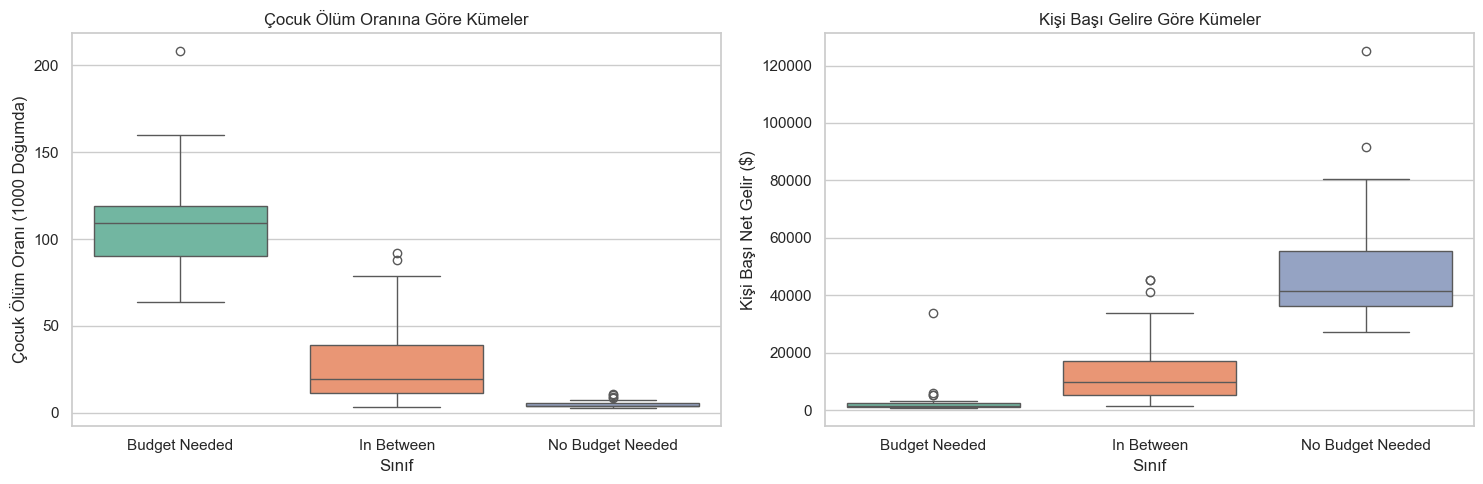

In [7]:
# Medyan gelire göre sınıf isimlerini tanımlıyoruz:
# En düşük gelirli küme -> "Budget Needed" (Yardım İhtiyacı Var)
# Orta gelirli küme -> "In Between" (Orta Gelir / Gelişmekte Olan)
# En yüksek gelirli küme -> "No Budget Needed" (Zengin / Gelişmiş)

sorted_clusters = cluster_summary['income'].sort_values().index

label_map = {
    sorted_clusters[0]: "Budget Needed",
    sorted_clusters[1]: "In Between",
    sorted_clusters[2]: "No Budget Needed"
}

df['Class'] = df['Cluster'].map(label_map)

# Kümelerin dağılımını gösteren Boxplot grafikleri
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df, x='Class', y='child_mort', ax=axes[0], palette='Set2', order=["Budget Needed", "In Between", "No Budget Needed"])
axes[0].set_title("Çocuk Ölüm Oranına Göre Kümeler")
axes[0].set_xlabel("Sınıf")
axes[0].set_ylabel("Çocuk Ölüm Oranı (1000 Doğumda)")

sns.boxplot(data=df, x='Class', y='income', ax=axes[1], palette='Set2', order=["Budget Needed", "In Between", "No Budget Needed"])
axes[1].set_title("Kişi Başı Gelire Göre Kümeler")
axes[1].set_xlabel("Sınıf")
axes[1].set_ylabel("Kişi Başı Net Gelir ($)")

plt.tight_layout()
plt.show()


## 7. Dünya Haritası Üzerinde Görselleştirme (Plotly Choropleth Map)

Elde edilen ülke gruplamalarının gerçek dünya konjonktürüne uygunluğunu Plotly dünya haritası üzerinde görüntülüyoruz.


In [8]:
fig = px.choropleth(
    df,
    locationmode="country names",
    locations="country",
    color="Class",
    title="Ülkelerin Sosyo-Ekonomik Kümeleme Haritası (Agglomerative + PCA)",
    color_discrete_map={
        "Budget Needed": "#e74c3c",    # Kırmızı
        "In Between": "#f39c12",       # Turuncu/Sarı
        "No Budget Needed": "#2ecc71"   # Yeşil
    },
    category_orders={"Class": ["Budget Needed", "In Between", "No Budget Needed"]}
)

fig.update_geos(fitbounds="locations", visible=True)
fig.show()


## 8. Türkiye ve Seçili Ülkelerin Model Karşılaştırması

Farklı modellerde (K-Means PCA, Agglomerative PCA, GMM PCA'sız) Türkiye ve diğer önemli ülkelerin sınıflarının değişip değişmediğine bakıyoruz.


In [9]:
# K-Means PCA ve GMM PCA'sız etiketlerini oluşturalım
kmeans_pca = KMeans(n_clusters=3, random_state=42).fit_predict(pca_df)
gmm_nopca = GaussianMixture(n_components=3, random_state=42).fit_predict(scaled_df)

def get_class_map(labels):
    temp_df = pd.DataFrame({'Cluster': labels, 'income': df['income']})
    meds = temp_df.groupby('Cluster')['income'].median().sort_values().index
    return temp_df['Cluster'].map({meds[0]: "Budget Needed", meds[1]: "In Between", meds[2]: "No Budget Needed"})

df['Class_KMeans_PCA'] = get_class_map(kmeans_pca)
df['Class_GMM_NoPCA'] = get_class_map(gmm_nopca)

# İlgilendiğimiz ülkeleri seçelim
sample_countries = ['Turkey', 'Poland', 'Germany', 'United States', 'Afghanistan', 'Nigeria', 'Brazil', 'China']
comparison_df = df[df['country'].isin(sample_countries)][
    ['country', 'Class', 'Class_KMeans_PCA', 'Class_GMM_NoPCA']
]

comparison_df.columns = ['Ülke', 'Agglomerative (PCA)', 'K-Means (PCA)', "GMM (PCA'sız)"]
comparison_df


,Ülke,Agglomerative (PCA),K-Means (PCA),GMM (PCA'sız)
0,Afghanistan,Budget Needed,Budget Needed,Budget Needed
22,Brazil,In Between,In Between,In Between
34,China,In Between,In Between,In Between
58,Germany,No Budget Needed,No Budget Needed,No Budget Needed
113,Nigeria,Budget Needed,Budget Needed,Budget Needed
121,Poland,In Between,In Between,In Between
153,Turkey,In Between,In Between,In Between
159,United States,No Budget Needed,No Budget Needed,No Budget Needed


## 9. Sonuç ve Ödev Değerlendirmesi


1. **PCA Gerekli miydi, PCA'sız Olur muydu?**
   * PCA'sız (9 ham ölçeklenmiş değişkenle) yapılan kümelemelerde de Türkiye, Afrika ve Avrupa ülkeleri fiziksel anlamda doğru kümelere düştü.
   * Ancak PCA kullandığımızda gürültülü boyutlar elendiği için **Silhouette skoru 0.34'ten 0.44'e yükseldi**. Bu da PCA'nın kümeler arası sınırları çok daha net ve matematiksel olarak kaliteli hale getirdiğini gösteriyor.

2. **Hangi Algoritma En İyi Sonucu Verdi?**
   * **K-Means ($k=3$)** ve **Hiyerarşik Kümeleme (Agglomerative, Ward)** en dengeli, açıklanabilir ve harita üzerinde mantıklı kümelemeleri üretti.
   * **DBSCAN ve HDBSCAN** gibi yoğunluk tabanlı modeller ise veri setinde belirgin kopukluklar (density gaps) olmadığı için başarısız oldu ve veriyi tek bir dev küme olarak algıladı.

3. **Harita ve Dünya Konjonktürü Mantıklı mı?**
   * Harita sonuçları güncel sosyo-ekonomik gerçeklikle tamamen örtüşmektedir:
     * **Kırmızı (Budget Needed)**: Sahra Altı Afrika ve Afganistan gibi çocuk ölüm oranı yüksek, kişi başı geliri düşük ülkeler.
     * **Sarı (In Between)**: **Türkiye**, Polonya/Doğu Avrupa, Brezilya ve Çin gibi gelişmekte olan orta gelir grubu ülkeleri.
     * **Yeşil (No Budget Needed)**: Batı Avrupa, Kuzey Amerika ve Avustralya gibi gelişmiş yüksek gelirli ülkeler.
